<a href="https://colab.research.google.com/github/Nirupamaistack/Digital-Communication/blob/main/Line%20Coding%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

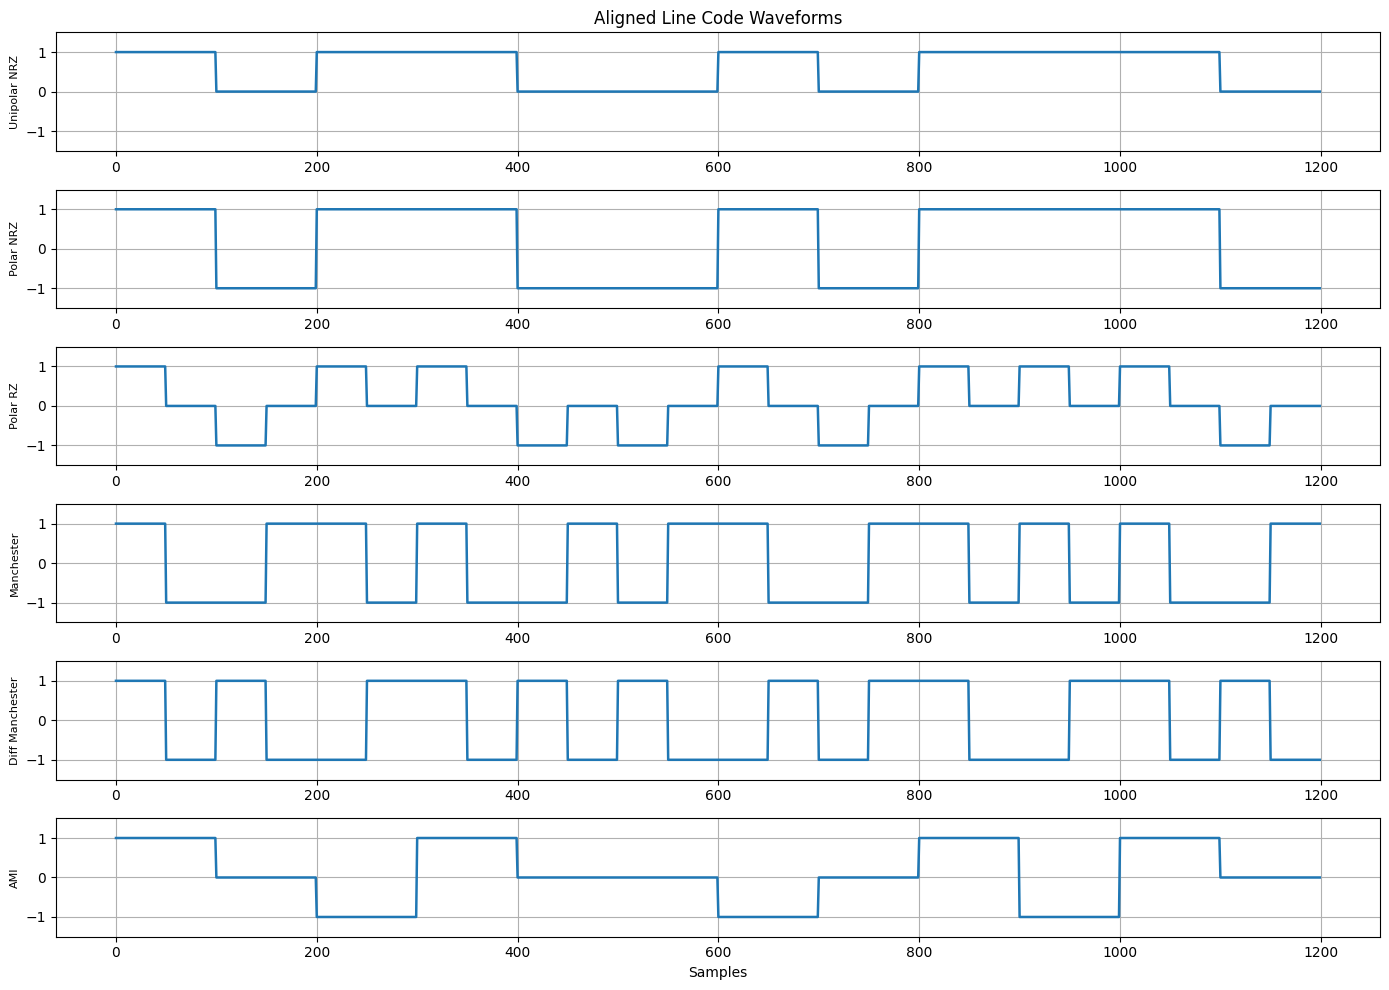

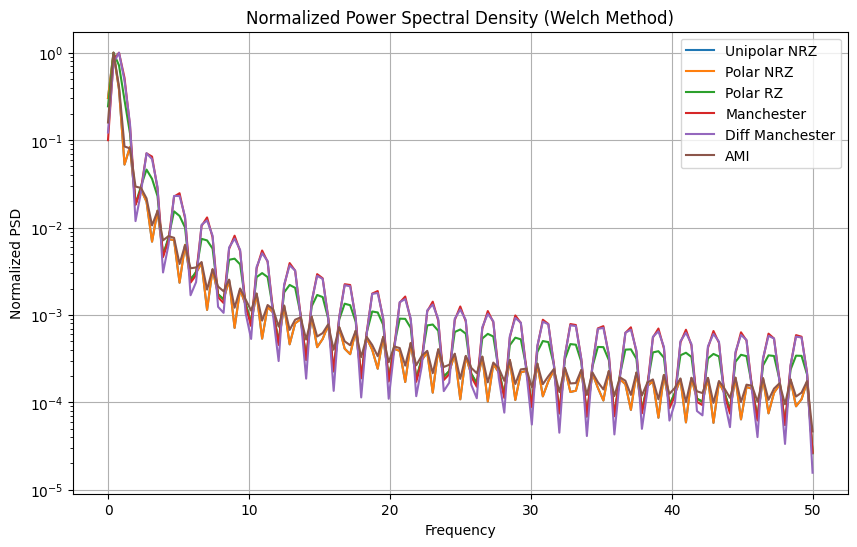

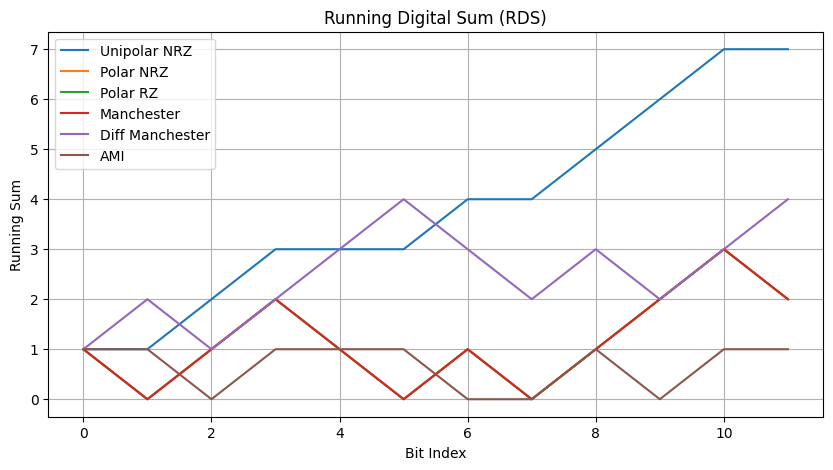

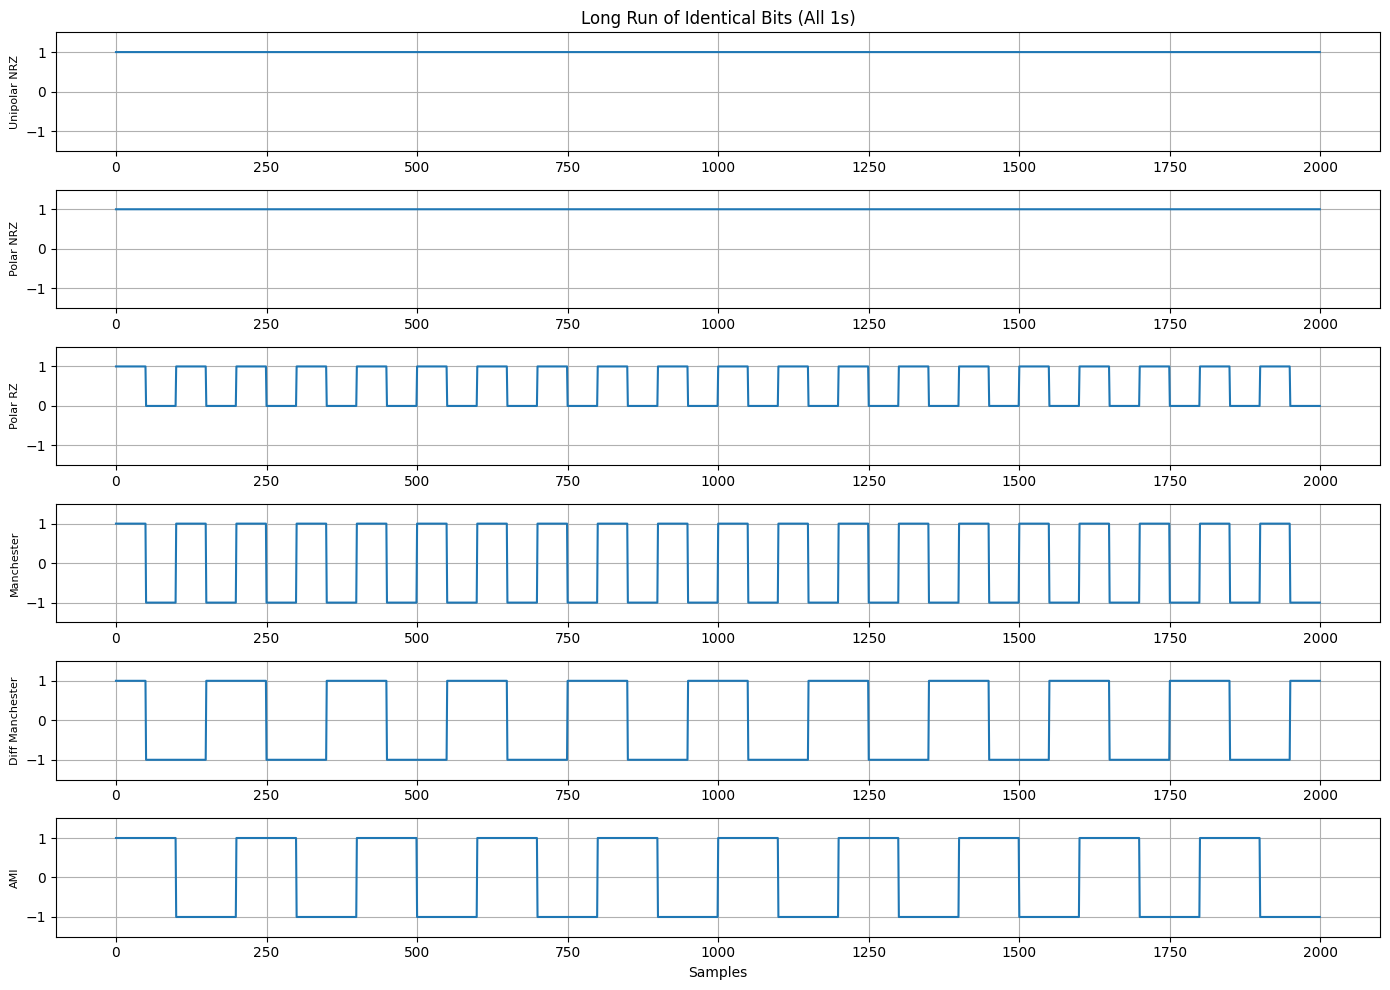


LINE CODE COMPARISON

Line Code            Avg Level  DC Content      Self Clocking  
Unipolar NRZ         0.583      High            No             
Polar NRZ            0.167      High            No             
Polar RZ             0.083      Low             No             
Manchester           0.000      Low             Yes            
Diff Manchester      0.000      Low             Yes            
AMI                  0.083      Low             No             

Validation Bit Sequence: [1 0 1 0 0 1 1 0]

Unipolar NRZ:
[1 1 0 0 1 1 0 0 0 0 1 1 1 1 0 0]

Polar NRZ:
[ 1  1 -1 -1  1  1 -1 -1 -1 -1  1  1  1  1 -1 -1]

Polar RZ:
[1, 0, -1, 0, 1, 0, -1, 0, -1, 0, 1, 0, 1, 0, -1, 0]

Manchester:
[1, -1, -1, 1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, 1]

Diff Manchester:
[1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, -1, 1, -1, 1]

AMI:
[1, 1, 0, 0, -1, -1, 0, 0, 0, 0, 1, 1, -1, -1, 0, 0]


In [1]:

# ==========================================================
# EXPERIMENT: LINE CODING AND PSD ANALYSIS
# MAKAUT ECE - Google Colab
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# -------------------------
# PARAMETERS
# -------------------------
bits = np.array([1,0,1,1,0,0,1,0,1,1,1,0])
sps = 100          # Samples per symbol
fs = sps           # Sampling frequency

# Long run identical bits
long_bits = np.ones(20, dtype=int)

# -------------------------
# LINE CODERS
# -------------------------
def unipolar_nrz(bits):
    return np.repeat(bits, sps)

def polar_nrz(bits):
    return np.repeat(2*bits-1, sps)

def polar_rz(bits):
    sig=[]
    for b in bits:
        level = 1 if b else -1
        sig.extend([level]*(sps//2))
        sig.extend([0]*(sps//2))
    return np.array(sig)

def manchester(bits):
    sig=[]
    for b in bits:
        if b:
            sig.extend([1]*(sps//2))
            sig.extend([-1]*(sps//2))
        else:
            sig.extend([-1]*(sps//2))
            sig.extend([1]*(sps//2))
    return np.array(sig)

def diff_manchester(bits):
    sig=[]
    level=1
    for b in bits:
        if b==0:
            level *= -1
        sig.extend([level]*(sps//2))
        level *= -1
        sig.extend([level]*(sps//2))
    return np.array(sig)

def ami(bits):
    sig=[]
    level=1
    for b in bits:
        if b:
            sig.extend([level]*sps)
            level *= -1
        else:
            sig.extend([0]*sps)
    return np.array(sig)

signals = {
    "Unipolar NRZ": unipolar_nrz(bits),
    "Polar NRZ": polar_nrz(bits),
    "Polar RZ": polar_rz(bits),
    "Manchester": manchester(bits),
    "Diff Manchester": diff_manchester(bits),
    "AMI": ami(bits)
}

# -------------------------
# GRAPH 1 : ALIGNED WAVEFORMS
# -------------------------
plt.figure(figsize=(14,10))

for i,(name,sig) in enumerate(signals.items(),1):
    plt.subplot(6,1,i)
    plt.plot(sig, lw=1.8)
    plt.ylim(-1.5,1.5)
    plt.ylabel(name, fontsize=8)
    plt.grid(True)
    if i==1:
        plt.title("Aligned Line Code Waveforms")

plt.xlabel("Samples")
plt.tight_layout()
plt.show()

# -------------------------
# GRAPH 2 : PSD USING WELCH
# -------------------------
plt.figure(figsize=(10,6))

for name,sig in signals.items():
    f,Pxx = welch(sig, fs=fs, nperseg=256)
    Pxx = Pxx/np.max(Pxx)
    plt.semilogy(f, Pxx, label=name)

plt.title("Normalized Power Spectral Density (Welch Method)")
plt.xlabel("Frequency")
plt.ylabel("Normalized PSD")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# GRAPH 3 : RUNNING DIGITAL SUM
# -------------------------
plt.figure(figsize=(10,5))

for name,sig in signals.items():
    rds = np.cumsum(sig[::sps])
    plt.plot(rds,label=name)

plt.title("Running Digital Sum (RDS)")
plt.xlabel("Bit Index")
plt.ylabel("Running Sum")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# GRAPH 4 : LONG RUN BEHAVIOR
# -------------------------
long_signals = {
    "Unipolar NRZ": unipolar_nrz(long_bits),
    "Polar NRZ": polar_nrz(long_bits),
    "Polar RZ": polar_rz(long_bits),
    "Manchester": manchester(long_bits),
    "Diff Manchester": diff_manchester(long_bits),
    "AMI": ami(long_bits)
}

plt.figure(figsize=(14,10))

for i,(name,sig) in enumerate(long_signals.items(),1):
    plt.subplot(6,1,i)
    plt.plot(sig)
    plt.ylim(-1.5,1.5)
    plt.ylabel(name, fontsize=8)
    plt.grid(True)
    if i==1:
        plt.title("Long Run of Identical Bits (All 1s)")

plt.xlabel("Samples")
plt.tight_layout()
plt.show()

# -------------------------
# OBSERVATION TABLE
# -------------------------
print("\nLINE CODE COMPARISON\n")
print("{:<20} {:<10} {:<15} {:<15}".format("Line Code","Avg Level","DC Content","Self Clocking"))

for name,sig in signals.items():
    avg=np.mean(sig)
    dc="High" if abs(avg)>0.1 else "Low"
    clock="Yes" if name in ["Manchester","Diff Manchester"] else "No"
    print("{:<20} {:<10.3f} {:<15} {:<15}".format(name,avg,dc,clock))

# -------------------------
# MANDATORY VALIDATION
# -------------------------
test_bits = np.array([1,0,1,0,0,1,1,0])

print("\nValidation Bit Sequence:", test_bits)

for name in signals.keys():
    if name=="Unipolar NRZ":
        encoded=np.repeat(test_bits,2)
    elif name=="Polar NRZ":
        encoded=np.repeat(2*test_bits-1,2)
    elif name=="Polar RZ":
        encoded=[]
        for b in test_bits:
            encoded.extend([1 if b else -1,0])
    elif name=="Manchester":
        encoded=[]
        for b in test_bits:
            encoded.extend([1,-1] if b else [-1,1])
    elif name=="Diff Manchester":
        encoded=[]
        level=1
        for b in test_bits:
            if b==0:
                level*=-1
            encoded.extend([level,-level])
            level=-level
    elif name=="AMI":
        encoded=[]
        level=1
        for b in test_bits:
            if b:
                encoded.extend([level,level])
                level*=-1
            else:
                encoded.extend([0,0])

    print(f"\n{name}:")
    print(encoded)